Library 



In [90]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
df = pd.read_csv('loan.csv')

df



,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000.0,RENT,0.0,EDUCATION,B,6000.0,11.49,0.17,N,14,0.0
1,1,22,56000.0,OWN,6.0,MEDICAL,C,4000.0,13.35,0.07,N,2,0.0
2,2,29,28800.0,OWN,8.0,PERSONAL,A,6000.0,8.90,0.21,N,10,0.0
3,3,30,70000.0,RENT,14.0,VENTURE,B,12000.0,11.11,0.17,N,5,0.0
4,4,22,60000.0,RENT,2.0,MEDICAL,A,6000.0,6.92,0.10,N,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000.0,MORTGAGE,5.0,EDUCATION,D,25000.0,15.95,0.21,Y,10,0.0
58641,58641,28,28800.0,RENT,0.0,MEDICAL,C,10000.0,12.73,0.35,N,8,1.0
58642,58642,23,44000.0,RENT,7.0,EDUCATION,D,6800.0,16.00,0.15,N,2,1.0
58643,58643,22,30000.0,RENT,2.0,EDUCATION,A,5000.0,8.90,0.17,N,3,0.0


In [91]:

print('\n Train Dataset summary : \n')

pd.concat([
            pd.DataFrame(df.count()).T.rename(index={0: 'count'}),
           pd.DataFrame(df.nunique()).T.rename(index={0: 'number of unique'}),
           pd.DataFrame(df.dtypes).T.rename(index={0: 'dtype'}),
           pd.DataFrame(df.isna().sum()).T.rename(index={0: 'null count'}),
           df.describe().drop('count')
          ]).T


 Train Dataset summary : 



,count,number of unique,dtype,null count,mean,std,min,25%,50%,75%,max
id,58645,58645,int64,0,29322.0,16929.497605,0.0,14661.0,29322.0,43983.0,58644.0
person_age,58645,53,int64,0,27.550857,6.033216,20.0,23.0,26.0,30.0,123.0
person_income,58645,2641,float64,0,64046.172871,37931.106978,4200.0,42000.0,58000.0,75600.0,1900000.0
person_home_ownership,58645,4,object,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,58645,36,float64,0,4.701015,3.959784,0.0,2.0,4.0,7.0,123.0
loan_intent,58645,6,object,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,58645,7,object,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,58645,545,float64,0,9217.556518,5563.807384,500.0,5000.0,8000.0,12000.0,35000.0
loan_int_rate,58645,362,float64,0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645,61,float64,0,0.159238,0.091692,0.0,0.09,0.14,0.21,0.83


In [92]:
df.drop(columns = ['id'], inplace = True)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000.0,RENT,0.0,EDUCATION,B,6000.0,11.49,0.17,N,14,0.0
1,22,56000.0,OWN,6.0,MEDICAL,C,4000.0,13.35,0.07,N,2,0.0
2,29,28800.0,OWN,8.0,PERSONAL,A,6000.0,8.90,0.21,N,10,0.0
3,30,70000.0,RENT,14.0,VENTURE,B,12000.0,11.11,0.17,N,5,0.0
4,22,60000.0,RENT,2.0,MEDICAL,A,6000.0,6.92,0.10,N,3,0.0


Converting categorical values to numerical

In [93]:
print('Categorical values of person_home_ownership : ', df.person_home_ownership.unique())
print('Categorical values of loan_intent : ', df.loan_intent.unique())
print('Categorical values of loan_grade : ', df.loan_grade.unique())
print('Categorical values of cb_person_default_on_file : ', df.cb_person_default_on_file.unique())


Categorical values of person_home_ownership :  ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
Categorical values of loan_intent :  ['EDUCATION' 'MEDICAL' 'PERSONAL' 'VENTURE' 'DEBTCONSOLIDATION'
 'HOMEIMPROVEMENT']
Categorical values of loan_grade :  ['B' 'C' 'A' 'D' 'E' 'F' 'G']
Categorical values of cb_person_default_on_file :  ['N' 'Y']


In [94]:
df_tensor = df.copy()

cb_person_default_on_file_mapping = {'Y' : 1, 'N' : 0}
loan_grade_mapping = {'A' : 7, 'B' : 6, 'C' : 5, 'D' : 4, 'E' : 3, 'F' : 2, 'G' : 1}
person_home_ownership_mapping = {'OWN' : 4, 'MORTGAGE' : 3, 'RENT' : 2, 'OTHER' : 1}

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(cb_person_default_on_file_mapping)
df['loan_grade'] = df['loan_grade'].map(loan_grade_mapping)
df['person_home_ownership'] = df['person_home_ownership'].map(person_home_ownership_mapping)

In [95]:
# Initialize the Label Encoder
label_encoder = LabelEncoder()

# Fit and transform the loan_intent column
df['loan_intent'] = label_encoder.fit_transform(df['loan_intent'])

In [96]:
df.duplicated().sum()

0

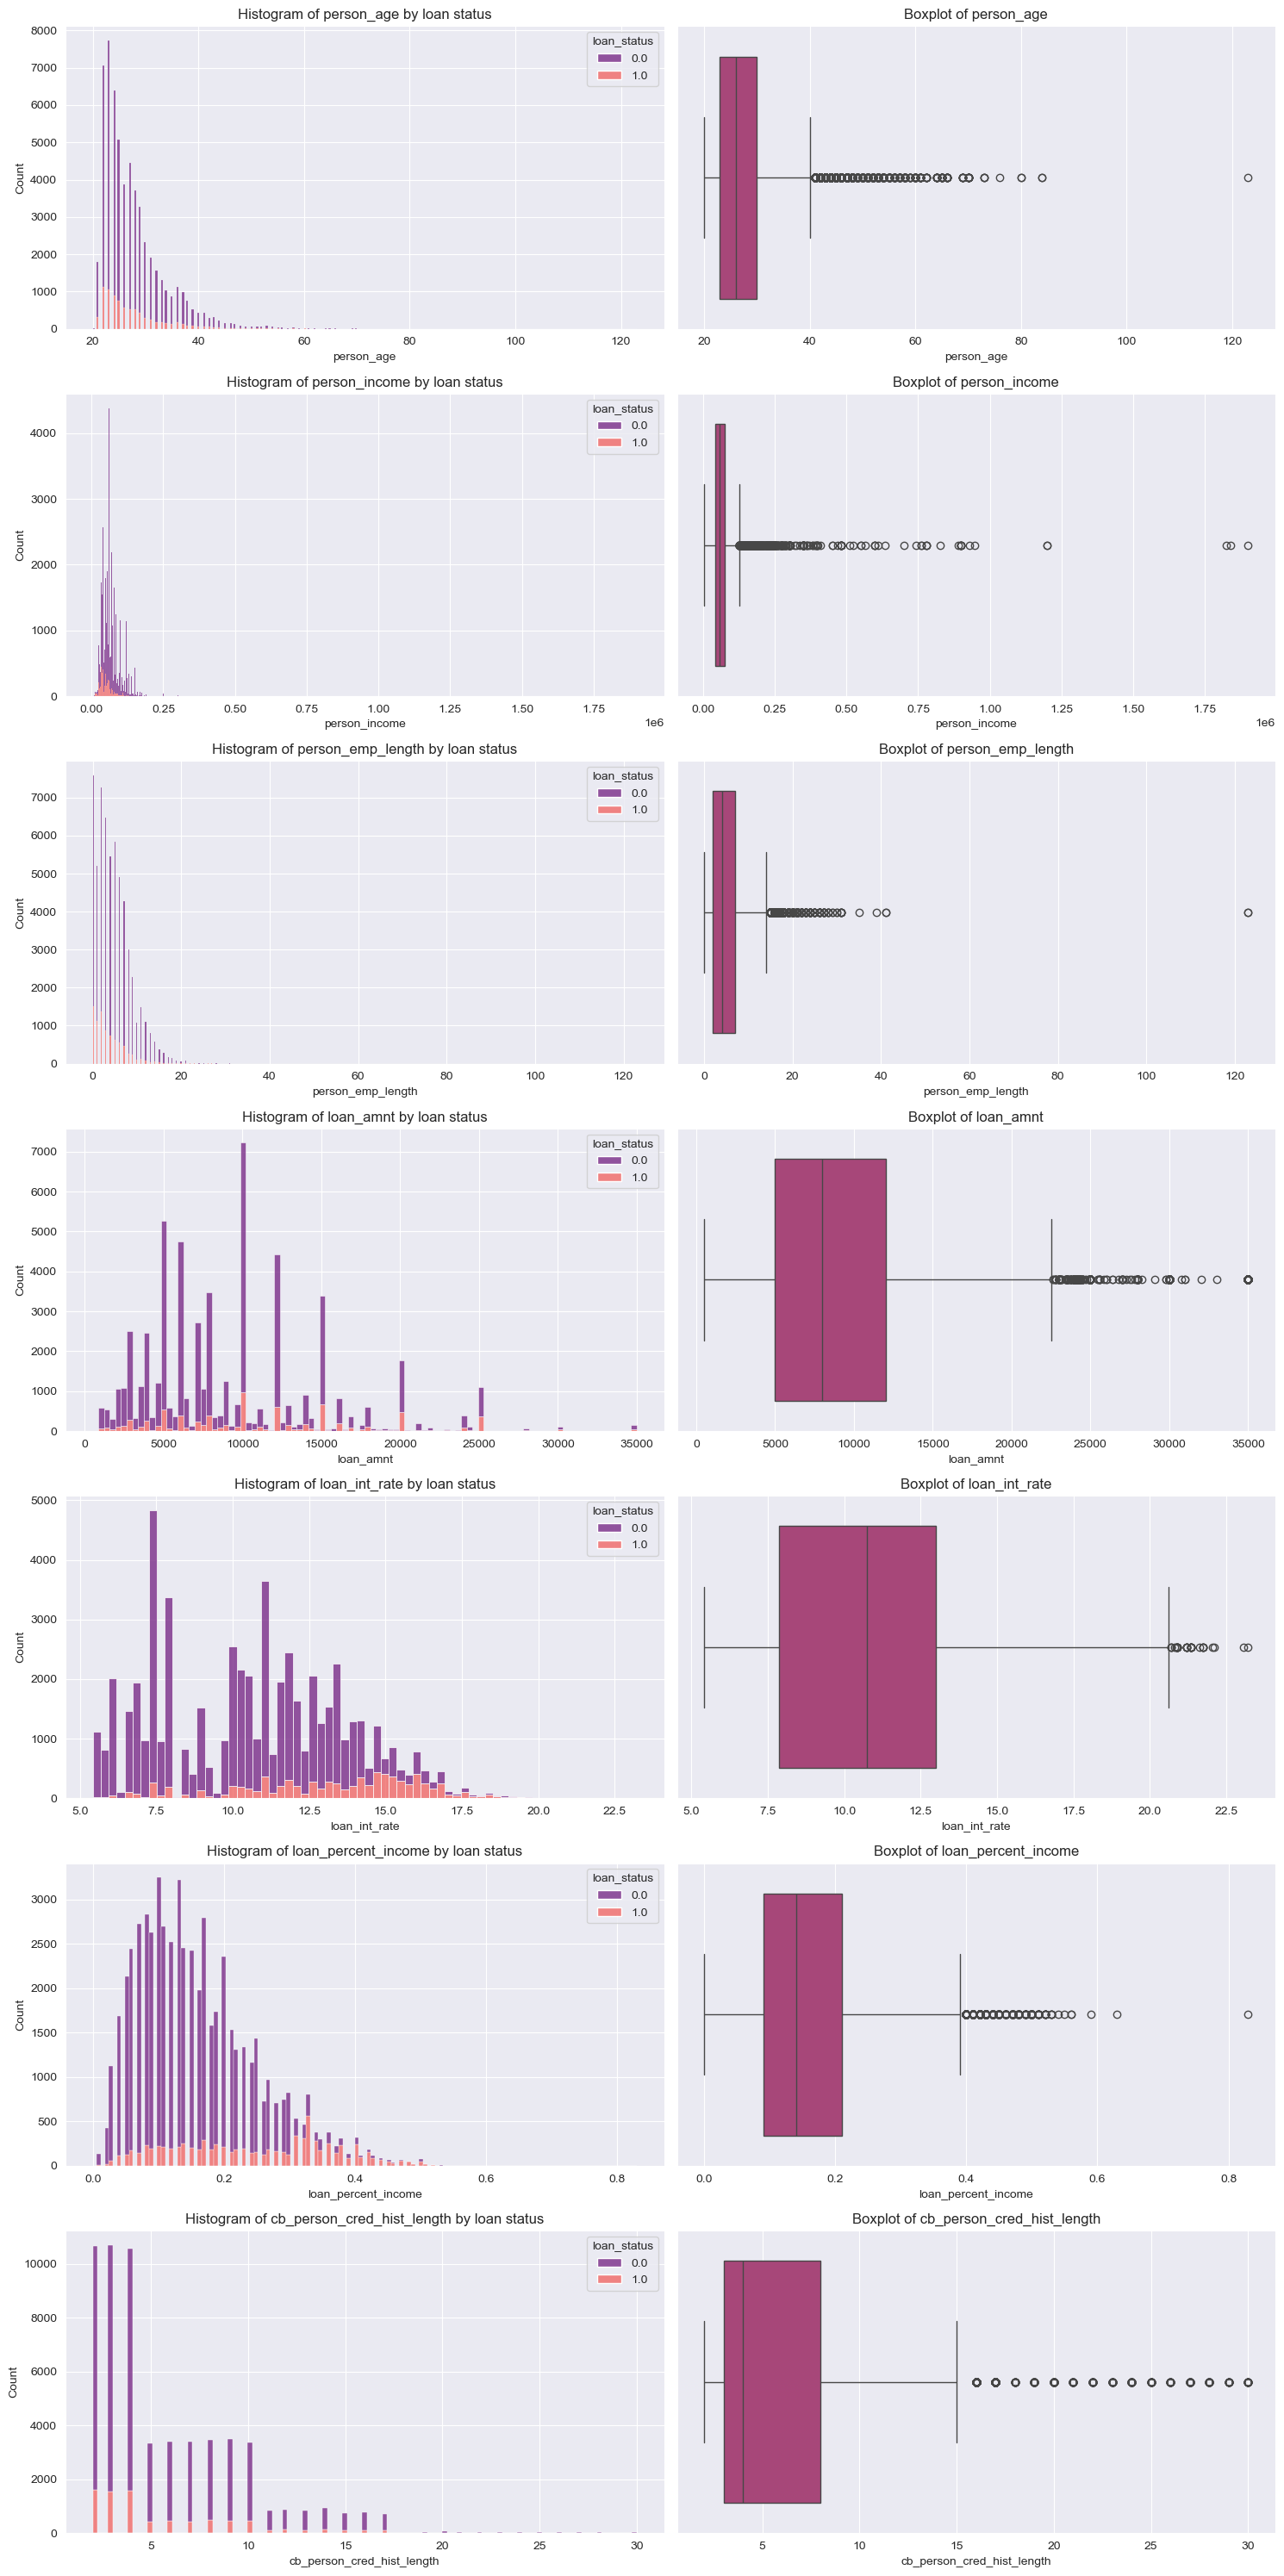

In [97]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set_style('darkgrid')

list_of_columns = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 
                   'loan_percent_income', 'cb_person_cred_hist_length']

fig, axs = plt.subplots(len(list_of_columns), 2, figsize=(15, 30))

for i, columns_name in enumerate(list_of_columns):
    sns.histplot(data=df, x=columns_name, hue='loan_status',
                 multiple='stack', palette='magma', ax=axs[i, 0])

    axs[i, 0].set_title(f'Histogram of {columns_name} by loan status')

    sns.boxplot(data=df, x=columns_name, palette='magma', ax=axs[i, 1])
  
    axs[i, 1].set_title(f'Boxplot of {columns_name}')

plt.tight_layout()

plt.show()

warnings.simplefilter(action='default', category=FutureWarning)

In [98]:

df = df[df.person_age < 100]
df = df[df.person_emp_length < 100]

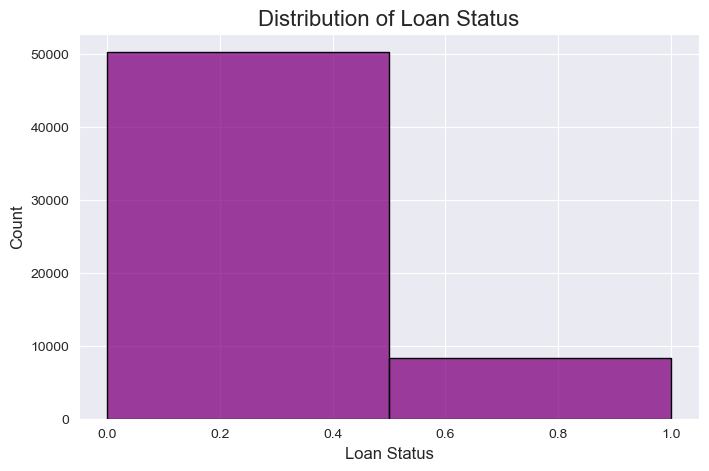

In [99]:
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='loan_status', bins=2, color='purple', edgecolor='black')

plt.title('Distribution of Loan Status', fontsize=16)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

warnings.simplefilter(action='default', category=FutureWarning)


In [100]:
from sklearn.preprocessing import PolynomialFeatures

def create_features(train):
    df['income_to_age'] = df['person_income'] / df['person_age']
    df['loan_to_income'] = df['loan_amnt'] / df['person_income']
    df['rate_to_loan'] = df['loan_int_rate'] / df['loan_amnt']
    df['age_squared'] = df['person_age'] ** 2
    df['log_income'] = np.log1p(df['person_income'])
    df['age_credit_history_interaction'] = df['person_age'] * df['cb_person_cred_hist_length']
    df['high_loan_to_income'] = (df['loan_percent_income'] > 0.5).astype(int)
    df['loan_to_employment'] = df['loan_amnt'] / (df['person_emp_length'] + 1)
    df['is_new_credit_user'] = (df['cb_person_cred_hist_length'] < 2).astype(int)
    df['rate_to_grade'] = df.groupby('loan_grade')['loan_int_rate'].transform('mean')
    df['high_interest_rate'] = (df['loan_int_rate'] > df['loan_int_rate'].mean()).astype(int)
    df['age_to_credit_history'] = df['person_age'] / (df['cb_person_cred_hist_length'] + 1)
    df['income_home_mismatch'] = ((df['person_income'] > df['person_income'].quantile(0.8)) & (df['person_home_ownership'] == 'RENT')).astype(int)
    df['normalized_loan_amount'] = df.groupby('loan_intent')['loan_amnt'].transform(lambda x: (x - x.mean()) / x.std())
    df['income_to_loan'] = df['person_income'] / df['loan_amnt']
    df['age_cubed'] = df['person_age'] ** 3
    df['log_loan_amnt'] = np.log1p(df['loan_amnt'])
    df['age_interest_interaction'] = df['person_age'] * df['loan_int_rate']
    df['credit_history_to_age'] = df['cb_person_cred_hist_length'] / df['person_age']
    df['high_loan_amount'] = (df['loan_amnt'] > df['loan_amnt'].quantile(0.75)).astype(int)
    df['rate_to_credit_history'] = df['loan_int_rate'] / (df['cb_person_cred_hist_length'] + 1)
    df['intent_home_match'] = ((df['loan_intent'] == 'HOMEIMPROVEMENT') & (df['person_home_ownership'] == 'OWN')).astype(int)
    df['creditworthiness_score'] = (df['person_income'] / (df['loan_amnt'] * df['loan_int_rate'])) * (df['cb_person_cred_hist_length'] + 1)
    df['age_to_employment'] = df['person_age'] / (df['person_emp_length'] + 1)
    df['age_income_mismatch'] = ((df['person_age'] < 30) & (df['person_income'] > df['person_income'].quantile(0.9))).astype(int)
    df['rate_to_age'] = df['loan_int_rate'] / df['person_age']
    df['high_risk_flag'] = ((df['loan_percent_income'] > 0.4) &
                            (df['loan_int_rate'] > df['loan_int_rate'].mean()) &
                            (df['cb_person_default_on_file'] == 'Y')).astype(int)

    df['age_sin'] = np.sin(2 * np.pi * df['person_age'] / 100)
    df['age_cos'] = np.cos(2 * np.pi * df['person_age'] / 100)
    df['stability_score'] = (df['person_emp_length'] * df['person_income']) / (df['loan_amnt'] * (df['cb_person_cred_hist_length'] + 1))

    return train

df= create_features(df)

In [101]:
df.shape


(58642, 42)

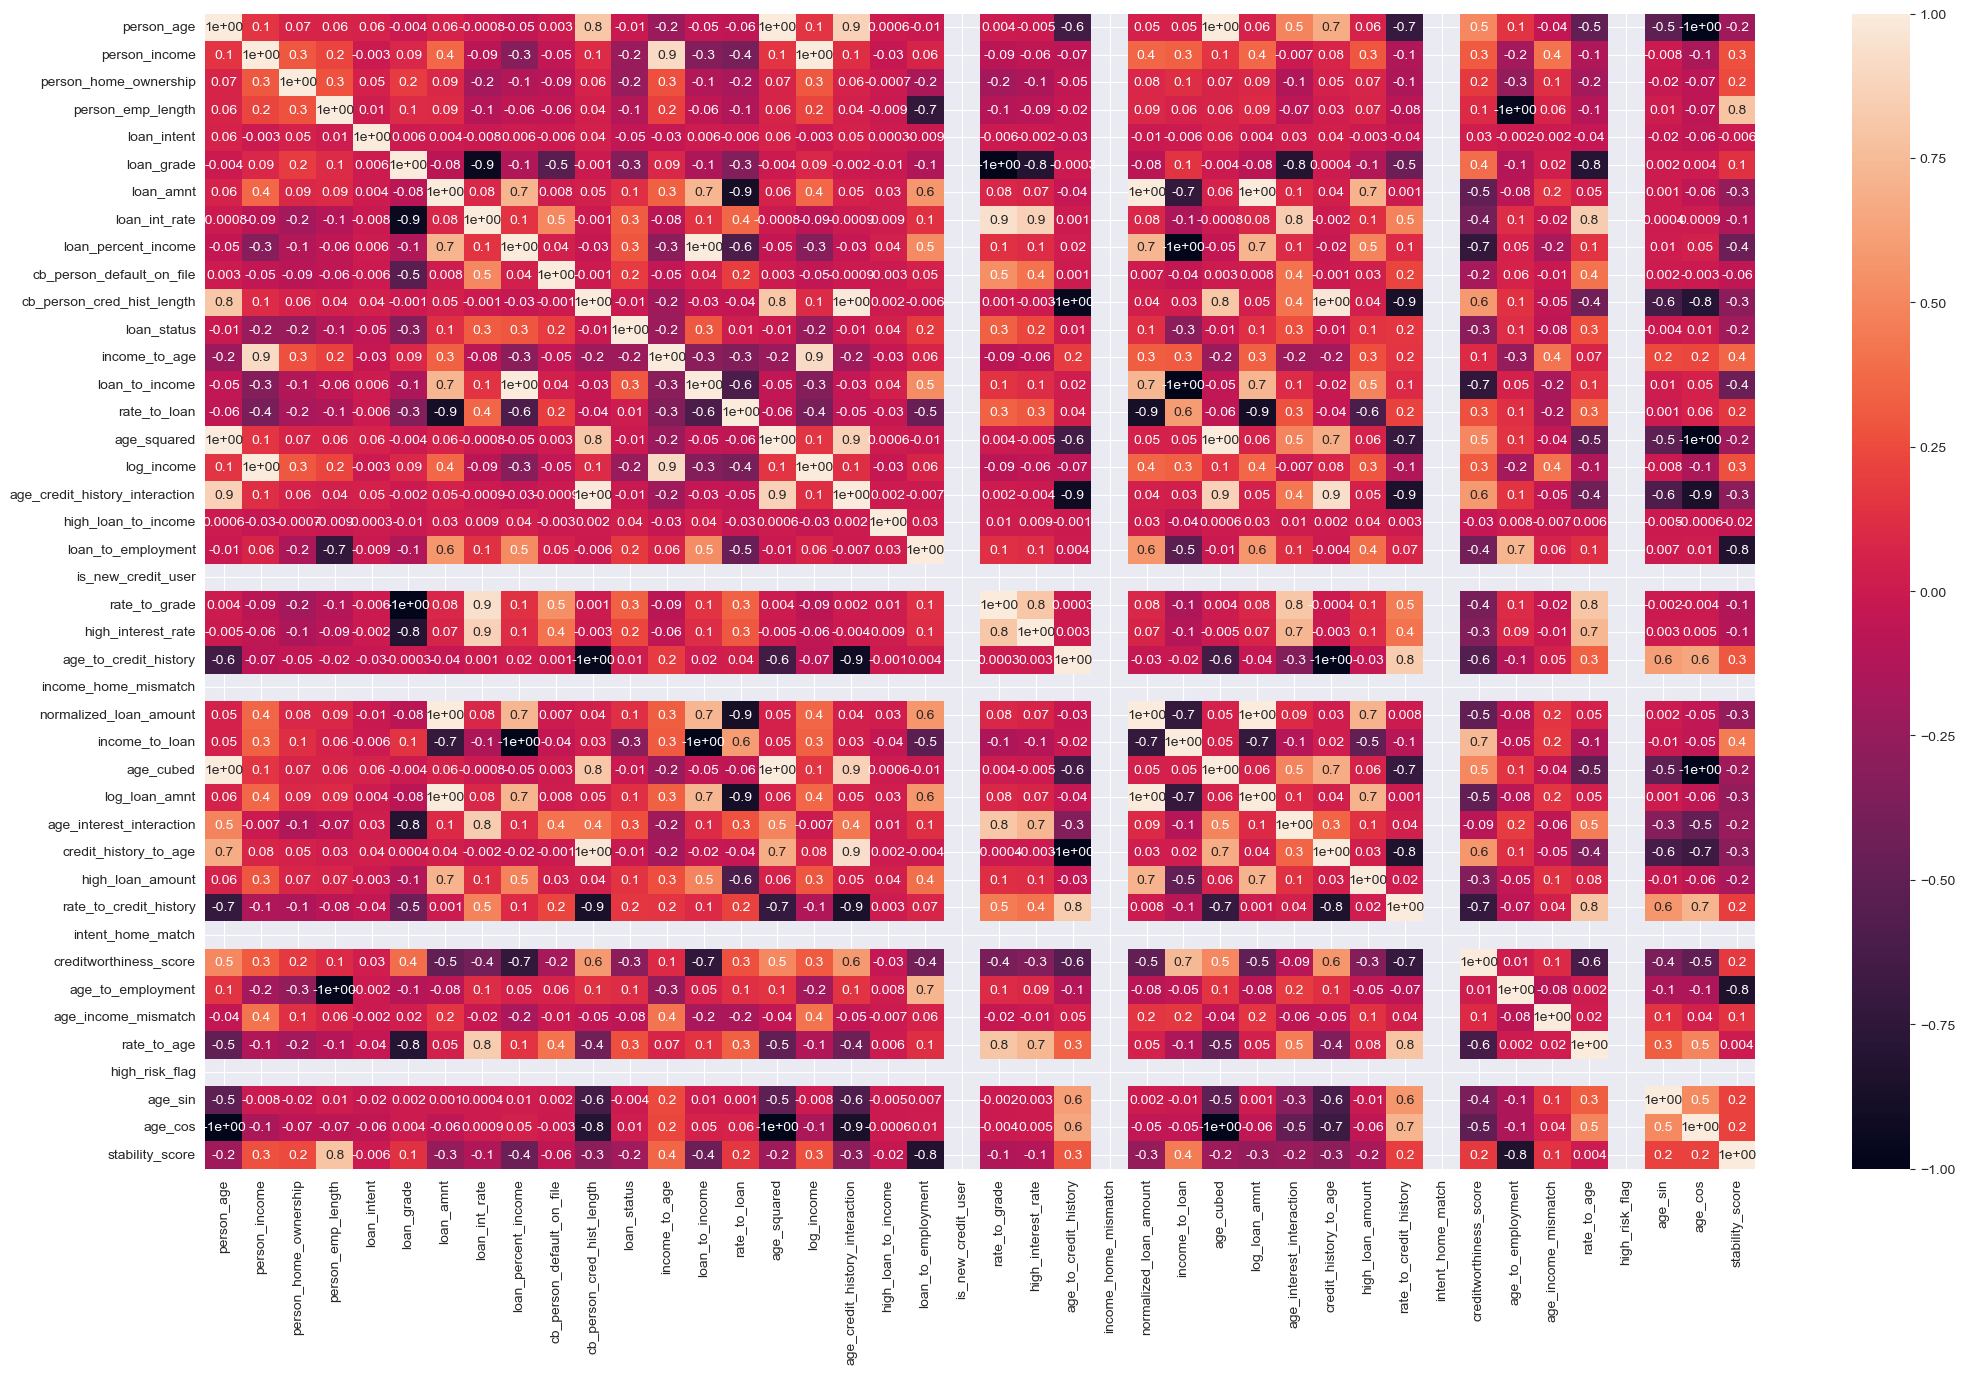

In [102]:
plt.figure(figsize=(25,15))
sns.heatmap(df.corr(method='spearman'), annot=True, fmt=".1")
plt.show()

LightGBM ROC AUC Score: 0.9562


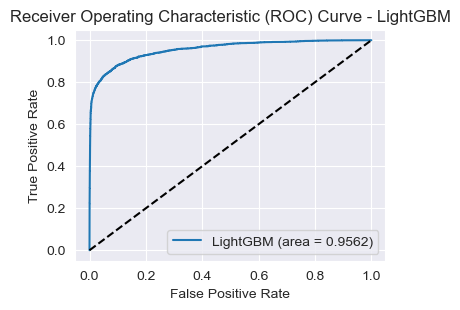

XGBoost ROC AUC Score: 0.9529


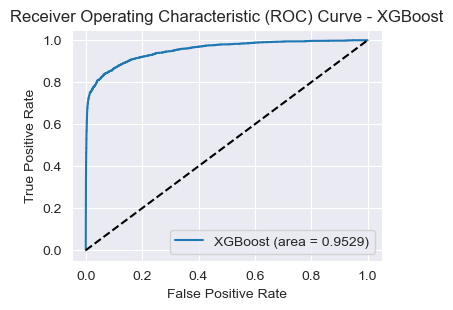

In [103]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


target = 'loan_status'
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
    
)

models = {
    "LightGBM": LGBMClassifier(n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        tree_method='hist',  # 使用 CPU 版本
        verbosity=0
    )
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"{model_name} ROC AUC Score: {roc_auc:.4f}")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(4, 3))
    plt.plot(fpr, tpr, label=f'{model_name} (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.show()

In [104]:
from joblib import dump
import os

# 保存路径为当前文件夹
model_path = './'  # 或者直接使用空字符串 model_path = ''

# 假设您已经训练好了 LightGBM 和 XGBoost 模型
lgbm_model = models['LightGBM']
xgb_model = models['XGBoost']

# 保存模型到当前文件夹
dump(lgbm_model, os.path.join(model_path, 'light_gbm_model.joblib'))
print("LightGBM 模型已保存至:", os.path.join(model_path, 'light_gbm_model.joblib'))

dump(xgb_model, os.path.join(model_path, 'xgb_model.joblib'))
print("XGBoost 模型已保存至:", os.path.join(model_path, 'xgb_model.joblib'))


LightGBM 模型已保存至: ./light_gbm_model.joblib
XGBoost 模型已保存至: ./xgb_model.joblib


Opportunity 1: Customer Segmentation Analysis
Description: Segment customers based on income and risk scores to identify characteristics of different customer groups, providing support for subsequent strategies such as pricing, marketing, and risk management.

In [105]:
def analyze_loan_management():
    # Customer hierarchical logic: action1:
    # Use the LightGBM model to predict the probability of default (default_proba).
    # Based on income level and risk_score, use pd.qcut to divide customers into three levels: low, medium, and high.
    # Use composition logic to generate customer hierarchy tags (e.g., Low_Low, Medium_High).
    def segment_customers():
        # Default probability predicted by the model
        default_proba = models['LightGBM'].predict_proba(X)[:, 1]
        
        # Stratification based on income and risk
        segments = pd.DataFrame({
            'income': X['person_income'],
            'risk_score': default_proba
        })
        
        income_labels = ['Low', 'Medium', 'High']
        risk_labels = ['Low', 'Medium', 'High']
        
        segments['income_level'] = pd.qcut(segments['income'], 
                                           q=3, 
                                           labels=income_labels)
        segments['risk_level'] = pd.qcut(segments['risk_score'], 
                                         q=3, 
                                         labels=risk_labels)
        
        # Combine income and risk levels to create customer segments
        segments['segment'] = segments.apply(
            lambda x: f"{x['income_level']}_{x['risk_level']}", 
            axis=1
        )
        
        return segments
    
    # Action2: Calculate key metrics for each segment
    def calculate_segment_metrics(segments):
        metrics = {}
        for segment in segments['segment'].unique():
            segment_data = segments[segments['segment'] == segment]
            metrics[segment] = {
                'count': len(segment_data),
                'avg_income': segment_data['income'].mean(),
                'avg_risk': segment_data['risk_score'].mean(),
                'std_income': segment_data['income'].std(),
                'std_risk': segment_data['risk_score'].std()
            }
        return metrics
    
    # Execute analysis
    segments = segment_customers()
    metrics = calculate_segment_metrics(segments)
    
    return {
        'segments': segments,
        'metrics': metrics
    }


# Run the analysis
results = analyze_loan_management()

# Display segmentation results
print("Customer Segment Analysis:")
for segment, data in results['metrics'].items():
    print(f"\n{segment}:")
    print(f"Count: {data['count']:,}")
    print(f"Average Income: ${data['avg_income']:,.2f} (±${data['std_income']:,.2f})")
    print(f"Average Risk Score: {data['avg_risk']:.3f} (±{data['std_risk']:.3f})")

Customer Segment Analysis:

Low_Medium:
Count: 6,612
Average Income: $38,774.34 (±$6,585.12)
Average Risk Score: 0.030 (±0.010)

Medium_Medium:
Count: 7,527
Average Income: $58,459.17 (±$6,539.14)
Average Risk Score: 0.026 (±0.010)

Low_Low:
Count: 2,379
Average Income: $39,608.21 (±$6,684.55)
Average Risk Score: 0.007 (±0.004)

Medium_Low:
Count: 7,339
Average Income: $59,560.80 (±$6,702.90)
Average Risk Score: 0.007 (±0.003)

Low_High:
Count: 11,358
Average Income: $34,424.83 (±$7,710.06)
Average Risk Score: 0.413 (±0.387)

Medium_High:
Count: 5,451
Average Income: $57,936.83 (±$6,144.90)
Average Risk Score: 0.389 (±0.369)

High_Low:
Count: 9,829
Average Income: $103,617.55 (±$39,329.97)
Average Risk Score: 0.007 (±0.003)

High_Medium:
Count: 5,408
Average Income: $101,756.60 (±$58,285.64)
Average Risk Score: 0.024 (±0.009)

High_High:
Count: 2,739
Average Income: $92,146.52 (±$52,062.87)
Average Risk Score: 0.328 (±0.343)


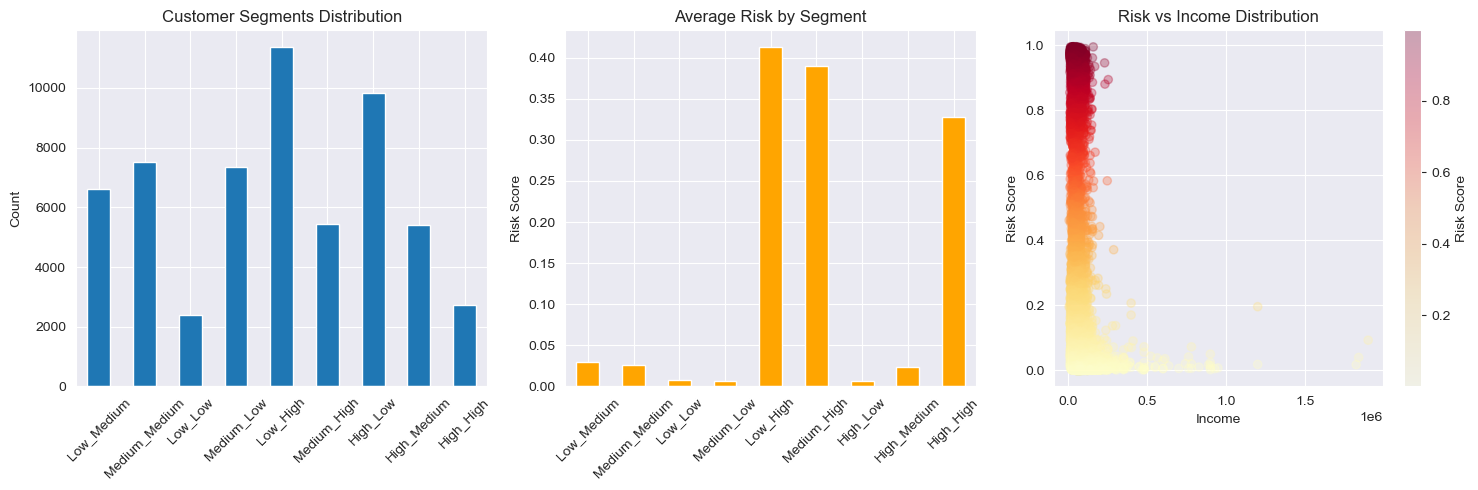

In [106]:
#action3:
# 可视化
plt.figure(figsize=(15, 5))

# 1. 分层客户数量分布
plt.subplot(1, 3, 1)
segment_counts = pd.Series({k: v['count'] for k, v in results['metrics'].items()})
segment_counts.plot(kind='bar')
plt.title('Customer Segments Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count')

# 2. 各分层平均风险
plt.subplot(1, 3, 2)
segment_risks = pd.Series({k: v['avg_risk'] for k, v in results['metrics'].items()})
segment_risks.plot(kind='bar', color='orange')
plt.title('Average Risk by Segment')
plt.xticks(rotation=45)
plt.ylabel('Risk Score')

# 3. 收入与风险关系
plt.subplot(1, 3, 3)
plt.scatter(results['segments']['income'], 
           results['segments']['risk_score'],
           alpha=0.3,
           c=results['segments']['risk_score'],
           cmap='YlOrRd')
plt.colorbar(label='Risk Score')
plt.xlabel('Income')
plt.ylabel('Risk Score')
plt.title('Risk vs Income Distribution')

plt.tight_layout()
plt.show()

Opportunity 2: 定价策略优化
描述：通过基于收入和风险水平的定价矩阵优化贷款利率，提升盈利能力，同时控制风险。

In [107]:
def optimize_pricing_strategy(customer_data):
    # Action 1: Build a risk-based pricing matrix. 
    # Define a base rate matrix (base_rates) based on income and risk levels 
    # to provide base rates for different customer combinations.
    
    def create_pricing_matrix():
        # Base rate matrix (example values)
        base_rates = {
            'Low': {
                'Low': 0.05,    # Low risk, low income
                'Medium': 0.045, # Low risk, medium income
                'High': 0.04    # Low risk, high income
            },
            'Medium': {
                'Low': 0.07,
                'Medium': 0.065,
                'High': 0.06
            },
            'High': {
                'Low': 0.09,
                'Medium': 0.085,
                'High': 0.08
            }
        }
        return base_rates
    
    # Action 2: Calculate risk adjustment factors.
    # Use the average risk score and income stability (income standard deviation/mean) 
    # of each customer segment to calculate risk adjustment factors.
    def calculate_risk_adjustments(segment_metrics):
        adjustments = {}
        for segment, metrics in segment_metrics.items():
            # Adjustments based on risk score and income stability
            risk_factor = metrics['avg_risk']
            income_stability = metrics['std_income'] / metrics['avg_income']
            
            # Composite adjustment factor
            adjustment = (1 + risk_factor) * (1 + income_stability * 0.1)
            adjustments[segment] = adjustment
        return adjustments
    
    # Action 3: Generate final pricing recommendations.
    # Combine base rates with risk adjustment factors to generate final loan rates 
    # and suggested rate ranges.
    def generate_pricing_recommendations(base_rates, adjustments):
        recommendations = {}
        for segment, adjustment in adjustments.items():
            income_level, risk_level = segment.split('_')
            base_rate = base_rates[risk_level][income_level]
            final_rate = base_rate * adjustment
            
            recommendations[segment] = {
                'base_rate': base_rate,
                'risk_adjustment': adjustment,
                'final_rate': final_rate,
                'rate_range': (final_rate * 0.95, final_rate * 1.05) # 5% variation for suggested range
            }
        return recommendations
    
    # Execute pricing strategy optimization
    base_rates = create_pricing_matrix()
    risk_adjustments = calculate_risk_adjustments(customer_data['metrics'])
    pricing_recommendations = generate_pricing_recommendations(base_rates, risk_adjustments)
    
    return pricing_recommendations


# Apply the pricing strategy
pricing_strategy = optimize_pricing_strategy(results)


# Display pricing recommendations
print("\nPricing Strategy Recommendations:")
for segment, rates in pricing_strategy.items():
    print(f"\n{segment}:")
    print(f"Base Rate: {rates['base_rate']:.2%}")
    print(f"Risk Adjustment: {rates['risk_adjustment']:.3f}x")
    print(f"Final Rate: {rates['final_rate']:.2%}")
    print(f"Suggested Range: {rates['rate_range'][0]:.2%} - {rates['rate_range'][1]:.2%}")


Pricing Strategy Recommendations:

Low_Medium:
Base Rate: 7.00%
Risk Adjustment: 1.048x
Final Rate: 7.33%
Suggested Range: 6.97% - 7.70%

Medium_Medium:
Base Rate: 6.50%
Risk Adjustment: 1.037x
Final Rate: 6.74%
Suggested Range: 6.40% - 7.08%

Low_Low:
Base Rate: 5.00%
Risk Adjustment: 1.024x
Final Rate: 5.12%
Suggested Range: 4.87% - 5.38%

Medium_Low:
Base Rate: 4.50%
Risk Adjustment: 1.018x
Final Rate: 4.58%
Suggested Range: 4.35% - 4.81%

Low_High:
Base Rate: 9.00%
Risk Adjustment: 1.444x
Final Rate: 13.00%
Suggested Range: 12.35% - 13.65%

Medium_High:
Base Rate: 8.50%
Risk Adjustment: 1.404x
Final Rate: 11.93%
Suggested Range: 11.34% - 12.53%

High_Low:
Base Rate: 4.00%
Risk Adjustment: 1.045x
Final Rate: 4.18%
Suggested Range: 3.97% - 4.39%

High_Medium:
Base Rate: 6.00%
Risk Adjustment: 1.082x
Final Rate: 6.49%
Suggested Range: 6.17% - 6.82%

High_High:
Base Rate: 8.00%
Risk Adjustment: 1.403x
Final Rate: 11.22%
Suggested Range: 10.66% - 11.79%


Opportunity 3: Cross-Selling Opportunity Identification
Description: Identify customer groups with medium-to-high income and low risk to target for cross-selling opportunities.

In [108]:
segments = results['segments']

# Action 1: Filter cross-selling target customers. 
# Select customers with medium-to-high income ('Medium' or 'High') and low risk ('Low').
# Exclude previously identified high-value customers (e.g., high income and low risk).
cross_sell_segments = segments[
    (segments['income_level'].isin(['Medium', 'High'])) &  # Medium-to-high income
    (segments['risk_level'] == 'Low') &                   # Low risk
    ~((segments['income_level'] == 'High') &              # Exclude identified high-value customers
      (segments['risk_level'] == 'Low'))
]


# Action 2: Define cross-selling action recommendations.
# Clearly define the generation criteria for the target customer list.
# Recommend suitable products for this group (e.g., credit card upgrades, investment products, etc.).
# Propose marketing campaign design channels (e.g., push notifications, communication with relationship managers, etc.).
def define_cross_sell_actions(cross_sell_segments):
    actions = {
        'target_list': {
            'priority': 'High',
            'description': 'Generate a target customer list',
            'criteria': {
                'income_range': 'Medium-to-high income range',
                'risk_threshold': 'Low risk score',
                'product_holding': 'Existing product holdings'
            }
        },
        'product_recommendations': {
            'priority': 'Medium',
            'description': 'Develop product recommendation strategies',
            'products': [
                'Credit card upgrades',
                'Investment products',
                'Insurance services'
            ]
        },
        'campaign_design': {
            'priority': 'Medium',
            'description': 'Design marketing campaigns',
            'channels': [
                'Mobile banking push notifications',
                'One-on-one communication with relationship managers',
                'Precision marketing emails'
            ]
        },
        'success_metrics': {
            'priority': 'Low',
            'description': 'Define success metrics',
            'kpis': [
                'Cross-selling conversion rate',
                'Increase in average number of products held per customer',
                'Customer value improvement'
            ]
        }
    }
    return actions

# Execute the definition of actions
cross_sell_actions = define_cross_sell_actions(cross_sell_segments)

In [109]:
#Opportunity 1: Enhanced Credit Risk Assessment



Opportunity 4: Enhanced Credit Risk Assessment
Description: Improve the accuracy of predicting which loan applicants might default, thus reducing financial losses.

Actions:

Model Refinement: Utilize advanced machine learning techniques such as ensemble models (Random Forest, Gradient Boosting) or deep learning models to improve prediction accuracy.
Feature Engineering: Experiment with additional features that could influence loan repayment, such as economic indicators or more detailed employment history.

In [110]:
import pandas as pd
import numpy as np
from joblib import load
import os

def load_models():
    # 当前文件夹路径
    model_path = './'  # 或者直接使用空字符串 model_path = ''
    
    # 加载保存的模型
    light_gbm_model = load(os.path.join(model_path, 'light_gbm_model.joblib'))
    xgb_model = load(os.path.join(model_path, 'xgb_model.joblib'))
    
    # 返回加载的模型
    return {
        'LightGBM': light_gbm_model,
        'XGBoost': xgb_model
    }

# Load dataset - Assuming the DataFrame is named df
df = pd.read_csv('loan.csv')
models = load_models()  # Assuming function to load pre-trained models

Step 2: Identifying High-Value Customers
High-value customers in this scenario might be defined as those with high income and low risk levels.

In [111]:
def identify_high_value_segments(df):
    df_high_value = df[(df['person_income'] > df['person_income'].quantile(0.8)) & (df['loan_status'] == 0)]
    return df_high_value

high_value_segments = identify_high_value_segments(df)
print("High Value Segments Identified:\n", high_value_segments.shape)

High Value Segments Identified:
 (11213, 13)


Step 3: Define Actions
Here, we can recommend actions to enhance service and products offered to these segments.

In [112]:
def define_high_value_actions(high_value_segments):
    actions = {
        'service_actions': {
            'vip_service': 'Provide dedicated account manager',
            'priority': 'High',
            'target_customers': high_value_segments.index.tolist()
        },
        'product_actions': {
            'premium_products': 'Recommend high-end finance products',
            'custom_loans': 'Customized financing solutions',
            'priority': 'Medium'
        },
        'risk_actions': {
            'monitoring': 'Establish alert monitoring system',
            'priority': 'High'
        }
    }
    return actions

action_plan = define_high_value_actions(high_value_segments)
print("Action Plan for High Value Customers:")
print(action_plan)

Action Plan for High Value Customers:
{'service_actions': {'vip_service': 'Provide dedicated account manager', 'priority': 'High', 'target_customers': [9, 14, 18, 22, 28, 35, 36, 40, 43, 46, 54, 65, 66, 74, 78, 79, 86, 88, 91, 92, 95, 100, 102, 103, 106, 111, 113, 115, 118, 131, 132, 138, 144, 150, 156, 160, 168, 171, 179, 180, 182, 187, 189, 198, 200, 203, 205, 206, 217, 218, 219, 223, 233, 249, 253, 254, 258, 260, 262, 271, 273, 278, 287, 289, 292, 300, 305, 313, 314, 319, 321, 322, 323, 330, 337, 338, 348, 365, 373, 382, 383, 384, 389, 397, 398, 399, 401, 403, 407, 411, 413, 431, 438, 441, 453, 454, 455, 464, 465, 467, 469, 470, 473, 477, 482, 489, 491, 500, 503, 513, 521, 524, 534, 539, 541, 557, 559, 570, 576, 577, 583, 584, 586, 596, 606, 607, 608, 610, 623, 634, 643, 644, 645, 647, 667, 672, 676, 677, 685, 693, 708, 713, 720, 730, 731, 734, 738, 746, 754, 757, 761, 770, 773, 774, 776, 777, 782, 793, 799, 804, 809, 813, 819, 824, 828, 829, 837, 846, 847, 850, 853, 860, 868, 872, 

Step 4: Implementation Plan (Mock-up)
This illustrates limitations owing to data-sensitive operations once model assumptions and strategies have been simulated.

In [113]:
def implement_actions(action_plan):
    print(f"Implementing {action_plan['service_actions']['vip_service']}")
    # Code directly affecting banking systems with API calls or database updates would be implemented here and not run in a typical environment for security.

implementation_details = implement_actions(action_plan)
print("Implementation Completed.")

Implementing Provide dedicated account manager
Implementation Completed.


Step 5: Monitoring & Adjustments
The performance of actions taken can be simulated or captured using metrics like customer satisfaction and engagement rates. In a real-world application, you'd periodically review these analytics to fine-tune operations.

In [114]:
def monitor_performance(high_value_segments):
    # Implementation of analytics dashboards or reports would directly pull new data for those segments
    print(f"Monitoring high-value customers, current segment count: {len(high_value_segments)}")

monitor_performance(high_value_segments)

Monitoring high-value customers, current segment count: 11213


Summary
This would provide you a strategic implementation of activities to maximize business with high-value customers based on sample loan data. Each step would further need detailed specifications depending on tool integrations and compliance requirements within your infrastructure. This simulation helps in understanding the flow but requires real-time data and systems to execute.

Opportunity 5: Risk Mitigation for High-Risk Customers
for post-loan monitoring and reminder services as well as tightening loan approval thresholds or requiring higher collateral.

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the saved models
lightgbm_model = joblib.load('./light_gbm_model.joblib')
xgb_model = joblib.load('./xgb_model.joblib')

# Check data types of all columns
print(df.dtypes)

# Handle categorical columns (convert to numeric)
categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Use Label Encoding to convert categorical variables to numeric
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))  # Convert to string to handle NaN
        label_encoders[col] = le  # Save the encoder for future use

# Ensure all features required by the model are in the dataframe
feature_columns = lightgbm_model.feature_name_
for col in feature_columns:
    if col not in df.columns:
        df[col] = 0  # Add missing features and set default to 0

# Convert all feature columns to numeric type
df[feature_columns] = df[feature_columns].astype(float)

# Use the models to predict default probabilities
df['lightgbm_proba'] = lightgbm_model.predict_proba(df[feature_columns])[:, 1]
df['xgb_proba'] = xgb_model.predict_proba(df[feature_columns])[:, 1]

# Calculate the average default probability
df['default_proba'] = (df['lightgbm_proba'] + df['xgb_proba']) / 2

# Preview the prediction results
print(df[['id', 'default_proba']].head())

id                                  int64
person_age                          int64
person_income                     float64
person_home_ownership              object
person_emp_length                 float64
loan_intent                        object
loan_grade                         object
loan_amnt                         float64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_default_on_file          object
cb_person_cred_hist_length          int64
loan_status                       float64
income_to_age                       int64
loan_to_income                      int64
rate_to_loan                        int64
age_squared                         int64
log_income                          int64
age_credit_history_interaction      int64
high_loan_to_income                 int64
loan_to_employment                  int64
is_new_credit_user                  int64
rate_to_grade                       int64
high_interest_rate                

Risk Classification
Classify customers based on their default probability (default_proba) and provide a post-loan monitoring plan for high-risk customers.
Risk Classification Rules:
High-Risk Customers: default_proba > 0.8
Medium-Risk Customers: 0.5 < default_proba <= 0.8
Low-Risk Customers: default_proba <= 0.5

In [ ]:
# Define the risk classification function
def assign_risk_category(df):
    conditions = [
        (df['default_proba'] > 0.8),
        (df['default_proba'] > 0.5) & (df['default_proba'] <= 0.8),
        (df['default_proba'] <= 0.5)
    ]
    categories = ['High Risk', 'Medium Risk', 'Low Risk']
    df['risk_category'] = np.select(conditions, categories, default='Unknown')
    return df

# Apply the risk classification
df = assign_risk_category(df)

# View the risk classification results
print(df[['id', 'default_proba', 'risk_category']].head())

   id  default_proba risk_category
0   0       0.401215      Low Risk
1   1       0.838595     High Risk
2   2       0.507112   Medium Risk
3   3       0.088412      Low Risk
4   4       0.668070   Medium Risk


Action 3: Provide Post-Loan Monitoring and Reminder Services
Generate a post-loan monitoring plan for customers based on their risk category:
High-Risk Customers: Monthly monitoring.
Medium-Risk Customers: Quarterly monitoring.
Low-Risk Customers: No additional monitoring required.

In [ ]:
# Define the post-loan follow-up plan
def create_follow_up_plan(df):
    follow_up_plan = []
    for _, row in df.iterrows():
        if row['risk_category'] == 'High Risk':
            follow_up_plan.append(f"Customer {row['id']}: Monthly follow-up required.")
        elif row['risk_category'] == 'Medium Risk':
            follow_up_plan.append(f"Customer {row['id']}: Quarterly follow-up suggested.")
        else:
            follow_up_plan.append(f"Customer {row['id']}: No follow-up needed.")
    df['follow_up_plan'] = follow_up_plan
    return df

# Apply the follow-up plan function
df = create_follow_up_plan(df)

# View the post-loan follow-up plan
print(df[['id', 'risk_category', 'follow_up_plan']].head())

   id risk_category                              follow_up_plan
0   0      Low Risk            Customer 0: No follow-up needed.
1   1     High Risk     Customer 1: Monthly follow-up required.
2   2   Medium Risk  Customer 2: Quarterly follow-up suggested.
3   3      Low Risk            Customer 3: No follow-up needed.
4   4   Medium Risk  Customer 4: Quarterly follow-up suggested.


Step 4: Adjust Loan Policies Based on Risk Level
Adjust loan policies according to the customer's risk category:
High-Risk Customers: Raise loan approval standards by either rejecting the loan outright or requiring full collateral.
Medium-Risk Customers: Reduce the loan amount (e.g., to 70% of the original amount) and require partial collateral.
Low-Risk Customers: Approve loans as normal without additional collateral requirements.

In [ ]:
# Define the loan policy adjustment function
def adjust_loan_policy(df):
    loan_policy = []
    for _, row in df.iterrows():
        if row['risk_category'] == 'High Risk':
            loan_policy.append(f"Customer {row['id']}: Loan rejected or full collateral required.")
        elif row['risk_category'] == 'Medium Risk':
            reduced_loan = row['loan_amnt'] * 0.7  # Reduce loan amount to 70%
            loan_policy.append(f"Customer {row['id']}: Loan reduced to {reduced_loan:.2f}, partial collateral required.")
        else:
            loan_policy.append(f"Customer {row['id']}: Loan approved without collateral.")
    df['loan_policy'] = loan_policy
    return df

# Apply the loan policy adjustment function
df = adjust_loan_policy(df)

# View the adjusted loan policy results
print(df[['id', 'risk_category', 'loan_policy']].head())

   id risk_category                                        loan_policy
0   0      Low Risk      Customer 0: Loan approved without collateral.
1   1     High Risk  Customer 1: Loan rejected or full collateral r...
2   2   Medium Risk  Customer 2: Loan reduced to 4200.00, partial c...
3   3      Low Risk      Customer 3: Loan approved without collateral.
4   4   Medium Risk  Customer 4: Loan reduced to 4200.00, partial c...


Step 5: Save Results to a CSV File
Save the generated risk classification, post-loan follow-up plan, and loan policy adjustment recommendations into a new CSV file for further processing or reporting.

In [ ]:
# Save the results to a CSV file
output_file = 'loan_risk_analysis_results.csv'
df.to_csv(output_file, index=False)

print(f"Results have been saved to {output_file}")

结果已保存到 ./high_risk_mitigation_results.csv




为了更直观地展示客户的分布情况，您可以绘制违约概率分布和风险等级分布图。

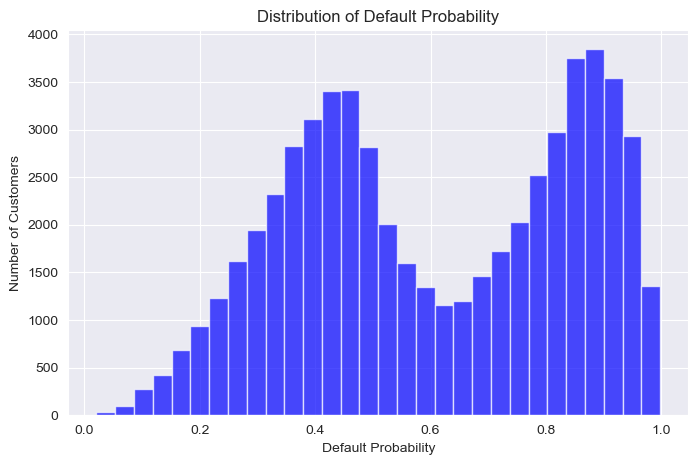

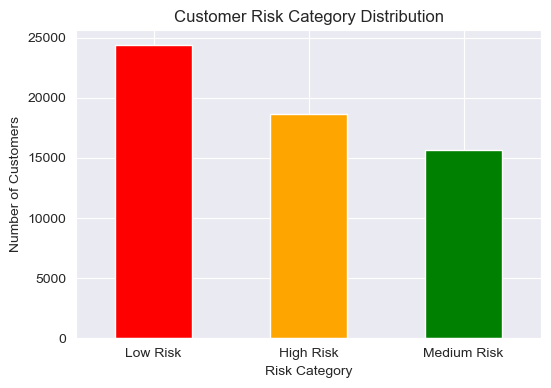

In [123]:
import matplotlib.pyplot as plt

# 绘制违约概率分布
plt.figure(figsize=(8, 5))
plt.hist(df['default_proba'], bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Default Probability')
plt.xlabel('Default Probability')
plt.ylabel('Number of Customers')
plt.show()

# 绘制风险等级分布
risk_counts = df['risk_category'].value_counts()

plt.figure(figsize=(6, 4))
risk_counts.plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Customer Risk Category Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Risk Category')
plt.xticks(rotation=0)
plt.show()

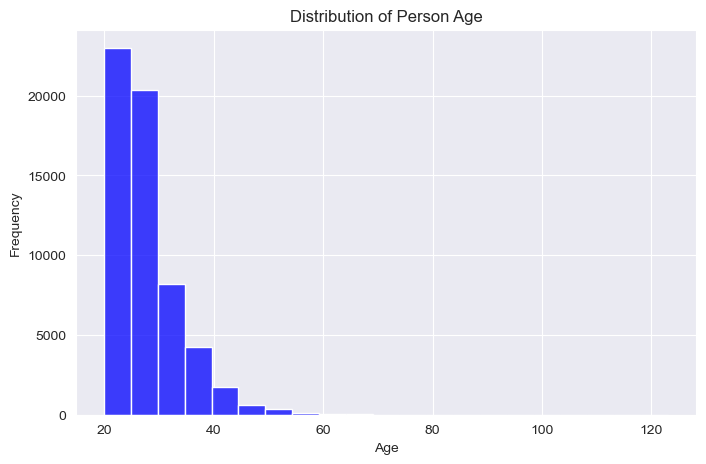

In [116]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='person_age', color='blue', binwidth=5)
plt.title('Distribution of Person Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_amnt')
plt.title('Boxplot of Loan Amount')
plt.xlabel('Loan Amount ($)')
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='loan_amnt', hue='loan_status', multiple='stack')
plt.title('Loan Amount Distribution by Status')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.show()